<a href="https://colab.research.google.com/github/deepan98raj-dotcom/git_notes_/blob/main/Session_22_Dession_tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dession Tree

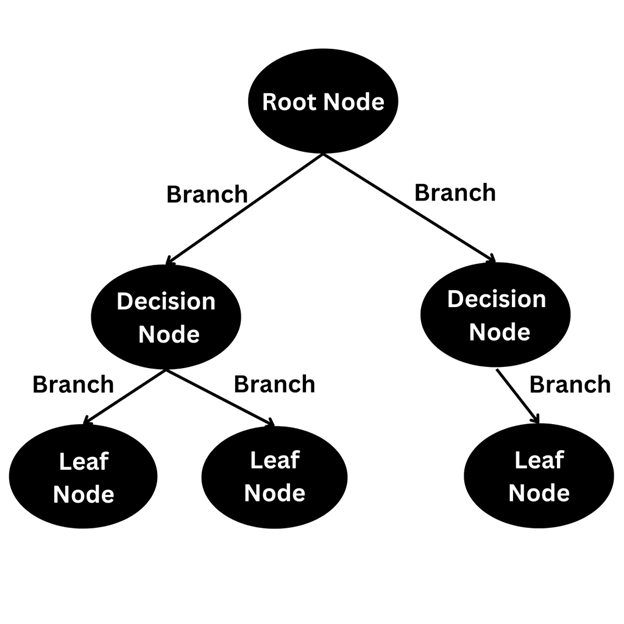

 Decision tree is one of the most popular machine learning algorithms used all along. Decision trees are used for both classification and regression problems

 1. Why Decision trees?

 Decision trees often mimic the human level thinking so its so simple to understand the data and make some good interpretations.

 Decision trees actually make you see the logic for the data to interpret.

 A decision tree follows a set of if-else conditions to visualize the data and according to the conditions.

 A decision tree is a tree where each node represents a feature(attribute), each link (branch) represents a decision(rule) and each leaf represents an outcome(categorical or continues value).


Important terminology In DT Root Node: This attribute is used for dividing the data into two or more sets. The feature attribute in this node is selected based on Attribute Selection Techniques

Branch or Sub-Tree : A part of the entire decision tree is called branch or sub-tree.

splitting: Dividing a node into two or more sub-nodes based on if-else conditions

Decision Node: After splitting the sub-nodes into further sub-nodes, then it is called as the decision node

leaf or Terminal node: This is the end of the decision tree where it cannot be split into further sub-nodes

Pruning:Removing a sub-node from the tree is called pruning

Types of Decision trees:

Types of Decision tree is based on the type of target variable

**Categorical variable Decision Tree:** DECISION Tree has continous target variable then it is called as Continous Variable Decision tree.

Three important Term in DT:

**Entropy(H)**

**Information Gain(IG)**

**Gini Impurity**

#### Entropy:
-> It select the best features/attribute in DT for splitting purpose

-> It helps to measure purity of split

-> Pure split is either get yes or no but not both

-> Eg. 3yes/2No - it is not pure But 3 yes/no - it is pure
he Shannon entropy formula for a dataset
 is:
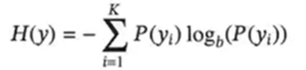



Where K is the number of classes, and P(yi) is the probality of class i

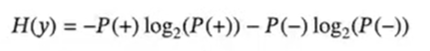




### Data Loading and Preparation

First, let's load a sample dataset. For this example, I'll assume you have a CSV file named `data.csv`. If your data is from a different source or has a different name, please adjust the `pd.read_csv()` line accordingly. Then, we'll separate the features (`X`) from the target variable (`y`).

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

# --- Step 1: Load your dataset ---
# Replace 'data.csv' with the path to your actual dataset file
try:
    df = pd.read_csv('data.csv')
except FileNotFoundError:
    print("data.csv not found. Please upload your CSV file or modify the path.")
    # As a fallback for demonstration, let's use a sample dataset if data.csv is not present
    from sklearn.datasets import load_iris
    iris = load_iris()
    df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
    df['target'] = iris.target
    print("Using Iris dataset as an example.")

display(df.head())

data.csv not found. Please upload your CSV file or modify the path.
Using Iris dataset as an example.


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


### Defining Features (X) and Target (y)

Now, we need to decide which columns are your features (the input to your model) and which column is your target (what you want to predict).

*   **`X`**: Contains the independent variables or features. These are the columns you'll use to make predictions.
*   **`y`**: Contains the dependent variable or target. This is the column you want to predict.

For the Iris dataset example, the `target` column is `y`, and all other columns are `X`. You'll need to adjust `df.drop()` and `df['target']` according to your specific dataset's column names.

In [ ]:
# --- Step 2: Define your features (X) and target (y) ---
# For the Iris dataset, 'target' is the dependent variable (y).
# For your own dataset, replace 'target' with the name of your target column.

X = df.drop('target', axis=1) # Features
y = df['target']             # Target variable

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)
display(X.head())
display(y.head())

Shape of X: (150, 4)
Shape of y: (150,)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


,target
0,0
1,0
2,0
3,0
4,0


### Splitting the Data into Training and Testing Sets

It's crucial to split your data into a training set and a testing set. The model learns from the training data, and its performance is evaluated on the unseen testing data. This helps in assessing how well the model generalizes to new data.

*   **`X_train`**: Training features
*   **`X_test`**: Testing features
*   **`y_train`**: Training target
*   **`y_test`**: Testing target

`test_size` specifies the proportion of the dataset to include in the test split (e.g., 0.2 means 20% for testing, 80% for training).
`random_state` ensures reproducibility of your split.

In [ ]:
# --- Step 3: Split the data into training and testing sets ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)


Shape of X_train: (120, 4)
Shape of X_test: (30, 4)
Shape of y_train: (120,)
Shape of y_test: (30,)


**Key Interpretations of Entropy Range:**

The value of entropy typically ranges from 0 to 1.

Complete Impurity (Entropy = 1): Occurs when data is perfectly split between classes (e.g 3 'yes'and 3'no') This indicates maximum uncertainty.

Complete Impurity (Entropy = 0) Occurs when all data points belong to a single class (eg.3'yes' and 0 'No'). This represents a 'leaf node' in decision tree terminology,where no furthur splitting is necessary because uncertainty is zero.




###1. Information Gain(IG)

* **What it does:** It compares the disorder (entropy) of data before and after a split
* **Meaning:** It measures **how much the confusion (uncertainly) decreased** after making the split.
* **How high should it be?** The higher the information Gain, the better the feature is.The algorithm will choose the feature with the highest information Gain to split the tree

###2. Gini impurity

* **What it does:** Just like entropy,it checks how'pure'or clean a split is (whether the data is sorted into correct categories or mixed up).

* **Why it's better:** Entropy uses complex math (logarithms) which takes more computer processing time.Gini impurity uses simple math,which is why python's scikit-learn uses it by default.

* **Range & meaning:**
* O means **Perfect** (all data points belong to just one group/class)
* 0.5 means Maximum confusion (the data is completely mixed 50-50 for a binary choice)

### What is Tree Pruning?

When a decision tree grow completely without limits, it tries to capture every single data point-including noise and errors. This leads to Overfitting (100% accuracy on training data, but poor performance on new test data).

pruning is the process of trimmimg down or cutting sections of a fully grown tree to reduce its complexity, lower variance, and help it generalize better on new data (just like regularization in Linear Regression).

There are two main types of pruning:

####1. Post-Pruning(backward Pruning)
  * **how it works:** you let the decision tree grow fullyand bulid the entire treefirst.Once it's completely grown, you start cutting down non-significant branches from the bottom up.

  * **How it decides what to cut:** It uses a cross-validation dataset to test the tree.it checks if checks if removing a node or a branch improves accuracy or keeps it stable

  * **The Rule:** If removing a node doesn't harm the performance (or actually improves it), you delete that branch and convert that node into a final leaf node.

####2. Pre-Pruning(forward Pruning)

  * **How it works**: instead of growing the full tree and cutting it later, pre-pruning stops the tree from growing too big in the first place.

  * **How it decides when to stop: It sets specific conditions or limits beforehand (e.g., maximum depth of th tree, minimum number of samples required to make a split).

  * **The rule: if a node doesn't meet the criteria the algorthm stops splitting prematurely , preventing unwanted or weak branches from ever being creeated.




How does the Decision Tree algorithm work?

In a decision tree, for predicting the class of the given dataset, the algorithm starts from the root node of the tree. This algorithm compares the values of root attribute with the record (real dataset) attribute and, based on the comparison, follow the branch and jumps to the next node.

for the next node, the algorithm again compares the attribute value with the other sub-nodes and move furthur.

It continues the process until it reaches the leaf node of the tree

The complete process can be better understood using the below algorithm:

Step-1: begin the tree with the root node,says S,which  contains the complete dataset

Step-2: Find the best attribute in the dataset using Attribute Selection Measure (ASM).Here it use Entropy or Gini Impurity

Step-3: Divide the S into subsets that contains possible values for the best attribute.

Step-4: Generate the decision tree node, which contains the best attribute.

Step-5: Recursively make new decision trees using the subsets of the dataset created in step-3. Continue this process until a stage is reached where you cannot further calasify the nodes and called the final node as a leaf node.


In [ ]:
from sklearn.tree import DecisionTreeClassifier
classifier = DecisionTreeClassifier(criterion='entropy',random_state = 0)
classifier.fit(X_train,y_train)

print(classifier.get_depth())

6


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


In [ ]:
import pandas as pd

# 1. Data Loading and Exploration

dataset = pd.read_csv('/content/Social_Network_Ads.csv')
print(dataset.head())

print(dataset.shape)

    User ID  Gender  Age  EstimatedSalary  Purchased
0  15624510    Male   19            19000          0
1  15810944    Male   35            20000          0
2  15668575  Female   26            43000          0
3  15603246  Female   27            57000          0
4  15804002    Male   19            76000          0
(400, 5)


In [ ]:
# 2. Defining Features (X) and Target (y)

# Extract independent variables (e.g., `Age` and `EstimatedSalary`) into `X` and the target variable (`Purchased`) into `y`.
X = dataset.iloc[:, [2,3]].values
y = dataset.iloc[:, -1].values

In [ ]:
# 3. Data Splitting

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 42)

In [ ]:
# 4. Feature Scaling

from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)


In [ ]:
# 5. Model Training

from sklearn.tree import DecisionTreeClassifier
classifier = DecisionTreeClassifier(criterion = 'entropy', random_state = 0)
classifier.fit(X_train, y_train)

#print(classifier.get_depth())

DecisionTreeClassifier(criterion='entropy', random_state=0)

In [ ]:
#6. Model Predicting the Test Set results

y_pred = classifier.predict(X_test)
print(y_pred)

[1 0 0 0 0 0 1 0 0 0 0 1 0 0 0 1 1 1 0 1 0 0 1 0 0 1 1 0 1 0 1 0 1 0 1 0 0
 0 0 0 1 0 0 1 0 1 0 0 0 0 0 1 0 0 0 0 1 1 0 0 0 0 1 0 0 1 1 0 0 1 0 0 0 0
 1 0 1 1 0 0 0 1 1 1 1 1 0 0 0 0 1 0 0 0 0 1 1 0 1 0]


### Making the Confusion matrix

In [ ]:
# 7. Evaluation Matrix (Confusion Matrix)

from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test,y_pred)
print(cm)

[[55  8]
 [ 9 28]]


In [ ]:
dataset.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [ ]:
# 8. Tree Structure Visualization

from sklearn import tree

fn=['Age','EstimatedSalary']
cn=['0','1']
fig, axes = plt.subplots(nrows = 1,ncols = 1,figsize = (50,30), dpi=300)
tree.plot_tree(classifier,
               feature_names = fn,
               class_names=cn,
               filled = True);
fig.savefig('imagename.png')


/tmp/ipykernel_686/2752814677.py:19: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


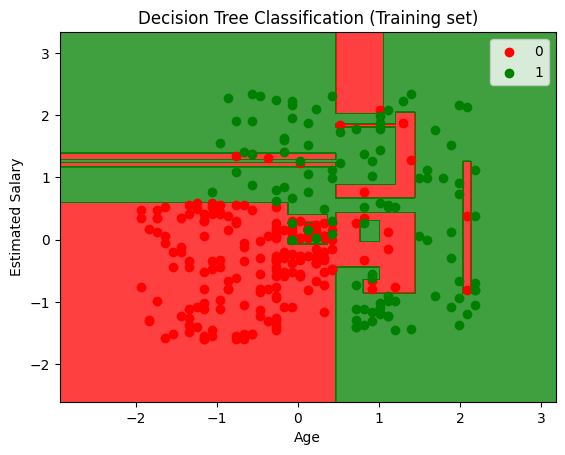

In [ ]:
from matplotlib.colors import ListedColormap
import numpy as np
import matplotlib.pyplot as plt

X_set, y_set = X_train, y_train

X1, X2 = np.meshgrid(
    np.arange(start = X_set[:, 0].min() - 1, stop = X_set[:, 0].max() + 1, step = 0.01),
    np.arange(start = X_set[:, 1].min() - 1, stop = X_set[:, 1].max() + 1, step = 0.01)
)

plt.contourf(X1, X2, classifier.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
             alpha = 0.75, cmap = ListedColormap(('red', 'green')))

plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())

for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],
                c = ListedColormap(('red', 'green'))(i), label = j)

plt.title('Decision Tree Classification (Training set)')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.legend()
plt.show()




/tmp/ipykernel_686/255507717.py:20: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(


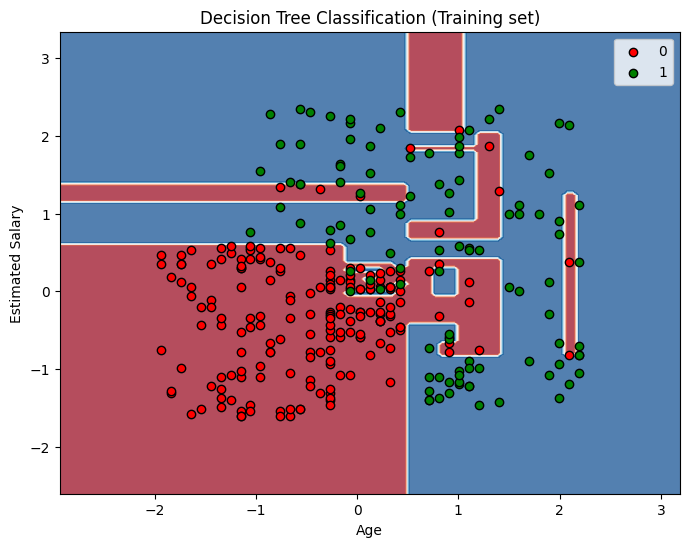

In [ ]:
# 9. Decision Boundary Visualization (Training Set)
from sklearn.inspection import permutation_importance, DecisionBoundaryDisplay
import matplotlib.pyplot as plt

X_set, y_set = X_train, y_train

fig, ax = plt.subplots(figsize=(8, 6))

DecisionBoundaryDisplay.from_estimator(
    classifier,
    X_set,
    response_method='predict',
    cmap=plt.cm.RdBu,
    alpha=0.75,
    ax=ax,
    xlabel='Age',
    ylabel='Estimated Salary',
)

for i,j in enumerate(np.unique(y_set)):
  ax.scatter(
    X_set[y_set == j, 0],
    X_set[y_set == j, 1],
    c=ListedColormap(('red', 'green'))(i),
    label=j,
    edgecolors='k'
  )
plt.title('Decision Tree Classification (Training set)')
plt.legend()
plt.show()
